# 08 — Scaling, tuning, ablations, and diagnostics

This stage checks whether the deterministic calibration is numerically and
statistically well behaved before uncertainty quantification is added.

We examine four questions:

1. Are residuals and regularisation terms scaled consistently?
2. How should the global regularisation strength \(\lambda\) be chosen?
3. What do the wing and confidence potentials contribute?
4. What do the Jacobian spectrum and residuals reveal about stability?


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.synthetic_data import (
    generate_synthetic_option_data,
    save_synthetic_option_data,
)
from src.evaluation.diagnostics import (
    jacobian_spectrum,
    residual_summary,
    surface_rmse,
    weighted_residual_table,
)
from src.evaluation.tuning import (
    linearized_lambda_sweep,
    select_lambda_by_gcv,
)
from src.inverse.linearized_inverse import (
    finite_difference_jacobian,
    price_quotes_from_log_variance,
    quote_weights,
)
from src.inverse.parameterization import (
    local_volatility_from_log_variance,
    reference_log_variance_surface,
)
from src.regularization.operators import (
    build_regularization_matrix,
)
from src.regularization.potentials import (
    combine_potentials,
    confidence_potential,
    quote_confidence_surface,
    wing_potential,
)
from src.regularization.scaling import (
    build_nondimensional_regularization_matrix,
    scaled_quadratic_penalty,
)
from src.surfaces.synthetic_surfaces import (
    smile_surface,
)


## 1. Three forms of scaling

The project now treats scaling at three levels.

### Quote scaling

Each residual is divided by its estimated noise standard deviation:

$$
W_{ii}=\frac{1}{s_i}.
$$

A one-penny error in a liquid quote and a one-penny error in a noisy quote do
not receive the same weight.

### Parameter scaling

We estimate log local variance,

$$
u=\log(\sigma_{\mathrm{loc}}^2),
$$

which is dimensionless and guarantees positive local volatility.

### Grid scaling

The earlier operators included \(1/\Delta x\) and \(1/\Delta T\), giving
correct derivative units. This stage additionally maps both coordinates to the
unit interval and multiplies squared sums by the cell area. This makes penalty
magnitudes much more comparable when the calibration grid changes.


## 2. Demonstrate grid scaling

We evaluate the same smooth correction on a coarse grid and a fine grid.

Without quadrature scaling, the discrete penalty grows simply because the fine
grid contains more differences. The nondimensional integral-scaled penalty
should be much more stable.


In [3]:
def smooth_test_correction(maturities, x_values):
    x_mesh, maturity_mesh = np.meshgrid(
        x_values,
        maturities,
    )
    return (
        0.04
        * np.cos(np.pi * x_mesh / 0.8)
        * np.exp(-0.5 * maturity_mesh)
    )


coarse_T = np.linspace(0.10, 2.00, 5)
coarse_x = np.linspace(-0.40, 0.40, 9)
fine_T = np.linspace(0.10, 2.00, 9)
fine_x = np.linspace(-0.40, 0.40, 17)

coarse_correction = smooth_test_correction(
    coarse_T,
    coarse_x,
)
fine_correction = smooth_test_correction(
    fine_T,
    fine_x,
)

coarse_raw_R, _, _ = build_regularization_matrix(
    number_of_maturities=coarse_T.size,
    number_of_log_moneyness_points=coarse_x.size,
    maturity_spacing=coarse_T[1] - coarse_T[0],
    log_moneyness_spacing=coarse_x[1] - coarse_x[0],
    alpha_x=1.0,
    alpha_T=1.0,
    beta=0.1,
)
fine_raw_R, _, _ = build_regularization_matrix(
    number_of_maturities=fine_T.size,
    number_of_log_moneyness_points=fine_x.size,
    maturity_spacing=fine_T[1] - fine_T[0],
    log_moneyness_spacing=fine_x[1] - fine_x[0],
    alpha_x=1.0,
    alpha_T=1.0,
    beta=0.1,
)

coarse_scaled_R, _, _, coarse_scale_info = (
    build_nondimensional_regularization_matrix(
        maturities=coarse_T,
        log_moneyness=coarse_x,
        alpha_x=1.0,
        alpha_T=1.0,
        beta=0.1,
    )
)
fine_scaled_R, _, _, fine_scale_info = (
    build_nondimensional_regularization_matrix(
        maturities=fine_T,
        log_moneyness=fine_x,
        alpha_x=1.0,
        alpha_T=1.0,
        beta=0.1,
    )
)

scaling_comparison = pd.DataFrame(
    {
        "grid": ["coarse", "fine"],
        "raw_penalty": [
            scaled_quadratic_penalty(
                coarse_correction,
                coarse_raw_R,
            ),
            scaled_quadratic_penalty(
                fine_correction,
                fine_raw_R,
            ),
        ],
        "scaled_penalty": [
            scaled_quadratic_penalty(
                coarse_correction,
                coarse_scaled_R,
            ),
            scaled_quadratic_penalty(
                fine_correction,
                fine_scaled_R,
            ),
        ],
        "cell_area": [
            coarse_scale_info["cell_area"],
            fine_scale_info["cell_area"],
        ],
    }
)

scaling_comparison


,grid,raw_penalty,scaled_penalty,cell_area
0,coarse,0.215444,0.004564,0.031250
1,fine,0.758014,0.004044,0.007812


## 3. Load the synthetic quotes and define the calibration grid

We use the same quote data as Stages 6 and 7.

The tuning calculations use one Jacobian built at the constant reference.
This makes a full sweep over many \(\lambda\) values inexpensive.


In [4]:
data_path = (
    project_root
    / "data"
    / "synthetic"
    / "smile_quotes.csv"
)

if data_path.exists():
    synthetic_quotes = pd.read_csv(data_path)
    print("Loaded:", data_path)
else:
    synthetic_quotes = generate_synthetic_option_data(
        surface_function=smile_surface,
        spot=100.0,
        relative_noise=0.005,
        minimum_noise=0.01,
        random_seed=1234,
        number_of_strike_points=201,
        number_of_time_steps=160,
    )
    save_synthetic_option_data(
        synthetic_quotes,
        data_path,
    )
    print("Generated and saved:", data_path)

spot = 100.0
calibration_T = np.linspace(0.10, 2.00, 5)
calibration_x = np.linspace(-0.35, 0.35, 9)

reference_log_variance = reference_log_variance_surface(
    maturities=calibration_T,
    log_moneyness=calibration_x,
    reference_volatility=0.20,
)

print("Quotes:", len(synthetic_quotes))
print("Unknowns:", reference_log_variance.size)


Loaded: /mnt/data/dupire_audit/dupire_local_vol_project/data/synthetic/smile_quotes.csv
Quotes: 78
Unknowns: 45


## 4. Build scaled potential ablations

We compare four regularisers:

1. no potential;
2. wing potential only;
3. confidence potential only;
4. combined wing and confidence potential.

The smoothness and magnitude terms are held fixed.


In [5]:
wing = wing_potential(
    log_moneyness=calibration_x,
    maturities=calibration_T,
    strength=0.20,
    power=2.0,
    start=0.20,
)

confidence = quote_confidence_surface(
    log_moneyness=calibration_x,
    maturities=calibration_T,
    quote_log_moneyness=synthetic_quotes[
        "log_moneyness"
    ].to_numpy(),
    quote_maturities=synthetic_quotes[
        "maturity"
    ].to_numpy(),
    log_moneyness_bandwidth=0.09,
    maturity_bandwidth=0.30,
)

confidence_penalty = confidence_potential(
    confidence=confidence,
    strength=0.20,
)

potential_surfaces = {
    "none": np.zeros_like(wing),
    "wing": wing,
    "confidence": confidence_penalty,
    "combined": combine_potentials(
        wing,
        confidence_penalty,
    ),
}

regularization_matrices = {}

for name, potential in potential_surfaces.items():
    matrix, _, _, scale_information = (
        build_nondimensional_regularization_matrix(
            maturities=calibration_T,
            log_moneyness=calibration_x,
            alpha_x=0.005,
            alpha_T=0.002,
            beta=1e-4,
            potential=potential,
        )
    )
    regularization_matrices[name] = matrix

print("Nondimensional cell area:", scale_information["cell_area"])


Nondimensional cell area: 0.03125000000000001


## 5. Build the weighted pricing Jacobian once

The weighted Jacobian is

$$
A=WJ.
$$

Its singular values reveal which combinations of surface corrections strongly
or weakly affect option prices.


In [6]:
reference_prices, jacobian = finite_difference_jacobian(
    reference_log_variance=reference_log_variance,
    calibration_maturities=calibration_T,
    calibration_log_moneyness=calibration_x,
    quote_data=synthetic_quotes,
    spot=spot,
    finite_difference_step=1e-3,
    scheme="forward",
    number_of_strike_points=151,
    number_of_time_steps=120,
    verbose=True,
)

observed_prices = synthetic_quotes[
    "observed_call_price"
].to_numpy()
weights = quote_weights(
    synthetic_quotes,
    noise_column="noise_standard_deviation",
)
residual = observed_prices - reference_prices

spectrum = jacobian_spectrum(
    jacobian,
    weights,
)

print("Jacobian shape:", jacobian.shape)
print("Numerical rank:", spectrum["numerical_rank"])
print(
    "Weighted-Jacobian condition number:",
    f"{spectrum['condition_number']:.3e}",
)


Jacobian columns completed: 4/45
Jacobian columns completed: 8/45


Jacobian columns completed: 12/45
Jacobian columns completed: 16/45


Jacobian columns completed: 20/45
Jacobian columns completed: 24/45


Jacobian columns completed: 28/45
Jacobian columns completed: 32/45


Jacobian columns completed: 36/45
Jacobian columns completed: 40/45


Jacobian columns completed: 44/45
Jacobian columns completed: 45/45
Jacobian shape: (78, 45)
Numerical rank: 45
Weighted-Jacobian condition number: 6.106e+04


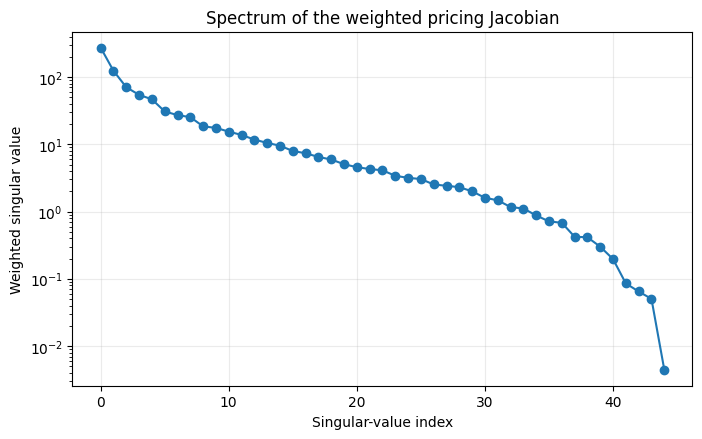

In [7]:
plt.figure(figsize=(8, 4.6))
plt.semilogy(
    spectrum["singular_values"],
    marker="o",
)
plt.xlabel("Singular-value index")
plt.ylabel("Weighted singular value")
plt.title("Spectrum of the weighted pricing Jacobian")
plt.grid(alpha=0.25)
plt.show()


## 6. Tune the global regularisation strength

For every candidate \(\lambda\), we solve the same weighted linearised inverse
problem.

Generalised cross-validation uses only observable quantities:

$$
\mathrm{GCV}(\lambda)
=
\frac{
\lVert A\widehat h_\lambda-b\rVert^2/m
}{
\left(1-\mathrm{df}_\lambda/m\right)^2
}.
$$

Here $$(\mathrm{df}_\lambda)$$ is the effective number of fitted degrees of
freedom.


In [8]:
lambda_values = np.logspace(
    -1,
    5,
    13,
)

lambda_results, lambda_solutions = (
    linearized_lambda_sweep(
        jacobian=jacobian,
        residual=residual,
        weights=weights,
        regularization_matrix=regularization_matrices[
            "combined"
        ],
        lambda_values=lambda_values,
    )
)

x_mesh, maturity_mesh = np.meshgrid(
    calibration_x,
    calibration_T,
)
true_volatility = smile_surface(
    x_mesh,
    maturity_mesh,
)

surface_rmse_values = []

for lambda_value in lambda_results["lambda"]:
    correction = lambda_solutions[
        float(lambda_value)
    ].reshape(
        reference_log_variance.shape,
        order="C",
    )
    estimated_volatility = (
        local_volatility_from_log_variance(
            reference_log_variance
            + correction
        )
    )
    surface_rmse_values.append(
        surface_rmse(
            estimated_volatility,
            true_volatility,
        )
    )

lambda_results["synthetic_surface_rmse"] = (
    surface_rmse_values
)

selected_lambda = select_lambda_by_gcv(
    lambda_results
)
truth_optimal_lambda = float(
    lambda_results.loc[
        lambda_results[
            "synthetic_surface_rmse"
        ].idxmin(),
        "lambda",
    ]
)

print("GCV-selected lambda:", selected_lambda)
print(
    "Truth-optimal lambda for this synthetic experiment:",
    truth_optimal_lambda,
)

lambda_results


GCV-selected lambda: 3162.2776601683795
Truth-optimal lambda for this synthetic experiment: 31622.776601683792


,lambda,weighted_data_misfit,weighted_rmse,regularization_penalty,objective,effective_degrees_of_freedom,gcv,correction_norm,synthetic_surface_rmse
0,0.100000,47.291425,0.778653,5.519614,47.843386,42.807228,2.978311,15.765030,0.799608
1,0.316228,47.766117,0.782551,2.926484,48.691553,41.691938,2.826236,11.203312,0.329185
2,1.000000,48.714488,0.790281,1.236613,49.951101,40.319508,2.676207,6.867203,0.135098
3,3.162278,50.082694,0.801303,0.437784,51.467090,38.623437,2.519455,4.012131,0.063483
4,10.000000,51.463406,0.812273,0.176407,53.227472,36.395662,2.319081,2.776346,0.042256
5,31.622777,52.961626,0.824012,0.089895,55.804340,33.433230,2.079858,2.205983,0.032257
6,100.000000,55.400948,0.842774,0.046564,60.057309,29.708824,1.853004,1.738863,0.024415
7,316.227766,59.759788,0.875301,0.022001,66.717219,25.423777,1.686261,1.356065,0.018397
8,1000.000000,66.668332,0.924512,0.009468,76.136811,20.909125,1.595441,1.065705,0.013628
9,3162.277660,75.509473,0.983906,0.004296,89.093877,16.562482,1.560374,0.856881,0.010080


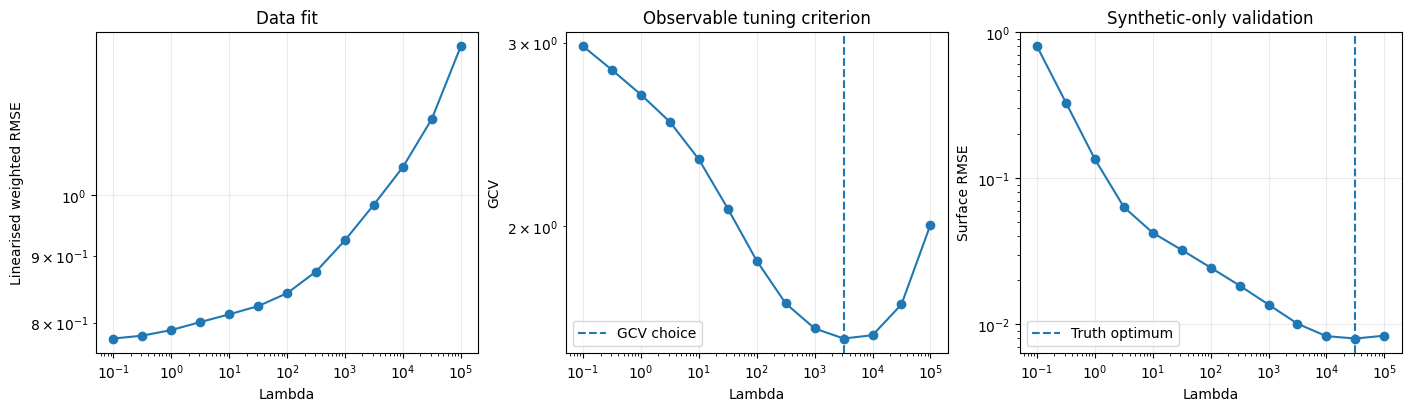

In [9]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.0),
    constrained_layout=True,
)

axes[0].loglog(
    lambda_results["lambda"],
    lambda_results["weighted_rmse"],
    marker="o",
)
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Linearised weighted RMSE")
axes[0].set_title("Data fit")
axes[0].grid(alpha=0.25)

axes[1].loglog(
    lambda_results["lambda"],
    lambda_results["gcv"],
    marker="o",
)
axes[1].axvline(
    selected_lambda,
    linestyle="--",
    label="GCV choice",
)
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("GCV")
axes[1].set_title("Observable tuning criterion")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].loglog(
    lambda_results["lambda"],
    lambda_results["synthetic_surface_rmse"],
    marker="o",
)
axes[2].axvline(
    truth_optimal_lambda,
    linestyle="--",
    label="Truth optimum",
)
axes[2].set_xlabel("Lambda")
axes[2].set_ylabel("Surface RMSE")
axes[2].set_title("Synthetic-only validation")
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.show()


## 7. Potential ablation study

We hold $$(\lambda)$$ fixed at the GCV-selected value and change only the
potential.

For each estimate, we also perform one nonlinear PDE repricing. This separates
linearised fit quality from the actual nonlinear price fit.


In [10]:
ablation_rows = []
ablation_surfaces = {}

for name, regularization_matrix in (
    regularization_matrices.items()
):
    sweep, solutions = linearized_lambda_sweep(
        jacobian=jacobian,
        residual=residual,
        weights=weights,
        regularization_matrix=regularization_matrix,
        lambda_values=[selected_lambda],
    )

    correction_vector = solutions[
        float(selected_lambda)
    ]
    estimated_log_variance = (
        reference_log_variance
        + correction_vector.reshape(
            reference_log_variance.shape,
            order="C",
        )
    )
    estimated_volatility = (
        local_volatility_from_log_variance(
            estimated_log_variance
        )
    )

    nonlinear_prices = (
        price_quotes_from_log_variance(
            log_variance_surface=estimated_log_variance,
            calibration_maturities=calibration_T,
            calibration_log_moneyness=calibration_x,
            quote_data=synthetic_quotes,
            spot=spot,
            number_of_strike_points=151,
            number_of_time_steps=120,
        )
    )

    nonlinear_weighted_rmse = np.sqrt(
        np.mean(
            (
                weights
                * (
                    nonlinear_prices
                    - observed_prices
                )
            )
            ** 2
        )
    )

    wing_mask = (
        np.abs(x_mesh) >= 0.25
    )

    ablation_rows.append(
        {
            "potential": name,
            "lambda": selected_lambda,
            "linearized_weighted_rmse": (
                sweep.iloc[0]["weighted_rmse"]
            ),
            "nonlinear_weighted_rmse": (
                nonlinear_weighted_rmse
            ),
            "surface_rmse": surface_rmse(
                estimated_volatility,
                true_volatility,
            ),
            "correction_norm": float(
                np.linalg.norm(correction_vector)
            ),
            "mean_absolute_wing_correction": float(
                np.mean(
                    np.abs(
                        correction_vector.reshape(
                            reference_log_variance.shape,
                            order="C",
                        )[wing_mask]
                    )
                )
            ),
        }
    )
    ablation_surfaces[name] = estimated_volatility

ablation_results = pd.DataFrame(
    ablation_rows
).sort_values(
    "nonlinear_weighted_rmse"
).reset_index(drop=True)

ablation_results


,potential,lambda,linearized_weighted_rmse,nonlinear_weighted_rmse,surface_rmse,correction_norm,mean_absolute_wing_correction
0,combined,3162.27766,0.983906,1.765129,0.010080,0.856881,0.074828
1,confidence,3162.27766,0.978393,1.794426,0.009577,0.896553,0.087249
2,wing,3162.27766,0.970284,1.810471,0.010719,0.940883,0.088627
3,none,3162.27766,0.962608,1.875027,0.010460,1.053665,0.115424


The best potential is not predetermined. On dense synthetic data, the
confidence potential may add little; with sparse real quotes, its contribution
should become more important. This is why the comparison is an ablation rather
than an assumption that more penalties are always better.


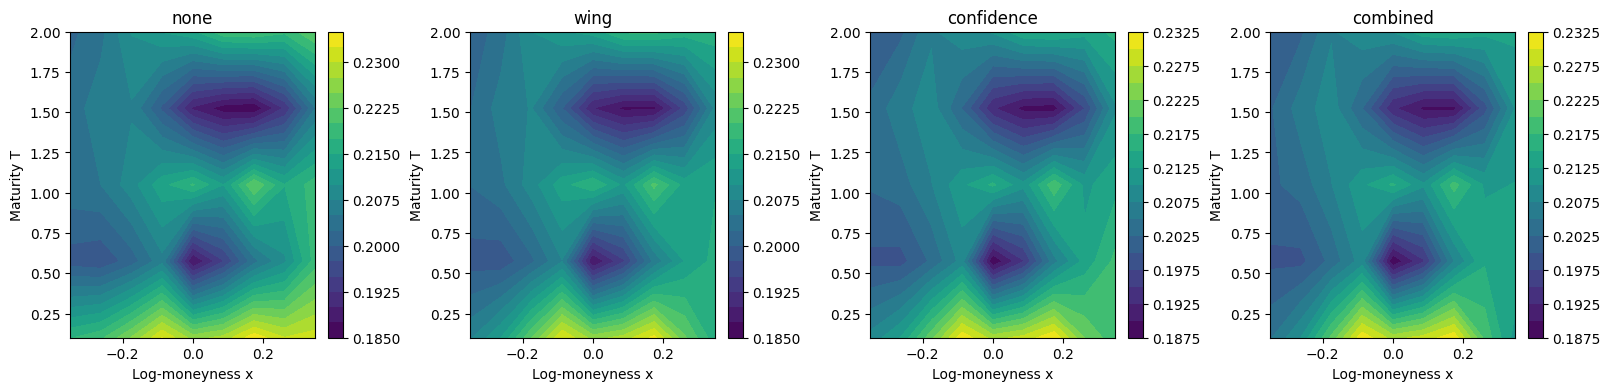

In [11]:
figure, axes = plt.subplots(
    1,
    4,
    figsize=(16, 3.8),
    constrained_layout=True,
)

for axis, name in zip(
    axes,
    ["none", "wing", "confidence", "combined"],
):
    contour = axis.contourf(
        calibration_x,
        calibration_T,
        ablation_surfaces[name],
        levels=20,
    )
    figure.colorbar(contour, ax=axis)
    axis.set_title(name)
    axis.set_xlabel("Log-moneyness x")
    axis.set_ylabel("Maturity T")

plt.show()


## 8. Residual diagnostics for the selected combined model

Ideally, weighted residuals should have no strong systematic pattern across
maturity or log-moneyness.

A weighted RMSE close to one means errors are broadly comparable to the assumed
quote-noise scale.


In [12]:
selected_correction = lambda_solutions[
    float(selected_lambda)
].reshape(
    reference_log_variance.shape,
    order="C",
)

selected_log_variance = (
    reference_log_variance
    + selected_correction
)

selected_prices = price_quotes_from_log_variance(
    log_variance_surface=selected_log_variance,
    calibration_maturities=calibration_T,
    calibration_log_moneyness=calibration_x,
    quote_data=synthetic_quotes,
    spot=spot,
    number_of_strike_points=151,
    number_of_time_steps=120,
)

residual_table = weighted_residual_table(
    quote_data=synthetic_quotes,
    predicted_prices=selected_prices,
)
selected_residual_summary = residual_summary(
    residual_table
)

selected_residual_summary


{'mean_weighted_residual': 0.9797472292409817,
 'weighted_residual_sd': 1.4682560351064513,
 'weighted_rmse': 1.7651290088353027,
 'mean_absolute_weighted_residual': 1.3448077974668884,
 'maximum_absolute_weighted_residual': 4.6079182314141764}

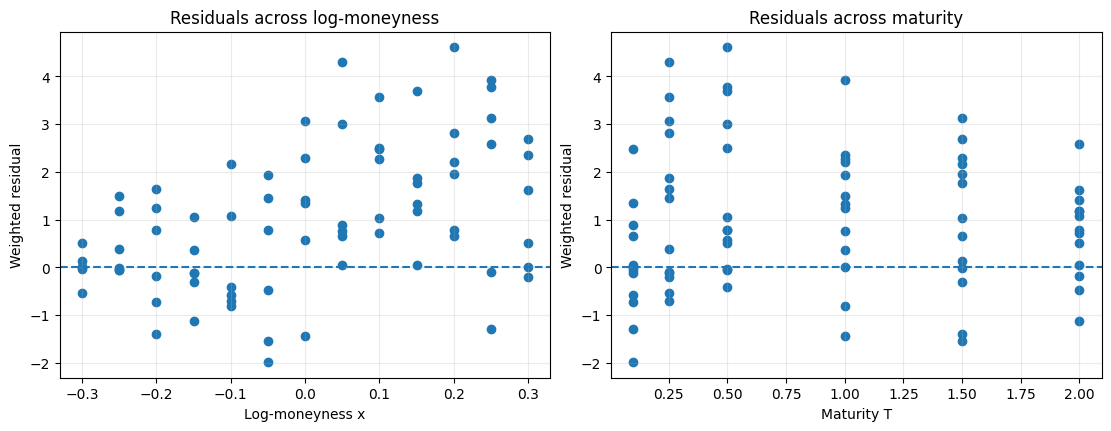

In [13]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
    constrained_layout=True,
)

axes[0].scatter(
    residual_table["log_moneyness"],
    residual_table["weighted_residual"],
)
axes[0].axhline(0.0, linestyle="--")
axes[0].set_xlabel("Log-moneyness x")
axes[0].set_ylabel("Weighted residual")
axes[0].set_title("Residuals across log-moneyness")
axes[0].grid(alpha=0.25)

axes[1].scatter(
    residual_table["maturity"],
    residual_table["weighted_residual"],
)
axes[1].axhline(0.0, linestyle="--")
axes[1].set_xlabel("Maturity T")
axes[1].set_ylabel("Weighted residual")
axes[1].set_title("Residuals across maturity")
axes[1].grid(alpha=0.25)

plt.show()


## 9. Save Stage 8 outputs

These files record the tuning sweep, potential ablations, residuals, and the
selected linearised estimate.


In [14]:
output_directory = (
    project_root
    / "outputs"
    / "stage_08"
)
output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

lambda_path = (
    output_directory
    / "lambda_sweep.csv"
)
ablation_path = (
    output_directory
    / "potential_ablations.csv"
)
residual_path = (
    output_directory
    / "selected_residuals.csv"
)
estimate_path = (
    output_directory
    / "selected_scaled_calibration.npz"
)

lambda_results.to_csv(
    lambda_path,
    index=False,
)
ablation_results.to_csv(
    ablation_path,
    index=False,
)
residual_table.to_csv(
    residual_path,
    index=False,
)

np.savez_compressed(
    estimate_path,
    calibration_maturities=calibration_T,
    calibration_x=calibration_x,
    reference_log_variance=reference_log_variance,
    estimated_log_variance=selected_log_variance,
    estimated_volatility=(
        local_volatility_from_log_variance(
            selected_log_variance
        )
    ),
    selected_lambda=selected_lambda,
    jacobian=jacobian,
    weights=weights,
    singular_values=spectrum["singular_values"],
)

print(lambda_path)
print(ablation_path)
print(residual_path)
print(estimate_path)


/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_08/lambda_sweep.csv
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_08/potential_ablations.csv
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_08/selected_residuals.csv
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_08/selected_scaled_calibration.npz


## Stage 8 result

The deterministic pipeline now includes:

- noise-scaled residuals;
- dimensionless log-variance parameters;
- nondimensional, quadrature-scaled regularisation;
- data-driven \(\lambda\) tuning through GCV;
- wing/confidence potential ablations;
- Jacobian spectrum diagnostics;
- quote-level residual diagnostics.

The next stage can use the selected deterministic solution and local Jacobian
to construct Gaussian/Laplace uncertainty estimates.
